### 2. Training
In this notebook, we proceed with the **training** of our classification algorithm, exploiting both news titles and texts.

#### 2.1 Simple title-text combination
First of all, we create a new column, called `combined`, in which we enter the titles and texts in succession. This is a very simple and seemingly naive way of combining information: we will compare it with other techniques later.

In [124]:
# Import the necessary libraries and the data
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the data and create the combined column
def fetch_data(name=''):
    df = pd.read_csv('data/news.csv', index_col=0)
    df.reset_index(drop=True, inplace=True)
    if 'title' in df.columns:
        df['combined'] = df['title'] + ' ' + df['text']
    return df

from sklearn.model_selection import train_test_split

data = pd.read_csv('data/news.csv', index_col=0)

X = data['title'] + " " + data['text']
y = data['label'].apply(lambda x: 1 if x == 'FAKE' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We now transform the combined texts according to the TFIDF value, described in the previous notebook. To do so, we use Scikit Learn's `TfidfVectorizer` function, where we set `max_features=10000`, meaning that we will build a vocabulary that only consider the top `max_features` ordered by term frequency across the corpus, and `ngram_range=(1,2)`, meaning that we will consider both unigrams (`n=1`) and bigrams (`n=2`) in the transformation.

*For some weird reason, some of the texts and titles result in null values. We fix this issue by simply removing these values from the dataframe, since it's a matter of just 30 items.*

In [125]:
# Remove null values from the data
X_train.dropna(inplace=True)
X_test.dropna(inplace=True)
# Remove the same rows from the target labels
y_train = y_train[y_train.index.isin(X_train.index)]
y_test = y_test[y_test.index.isin(X_test.index)]

# Reset the indexes
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [126]:
# Take a look at the structure of the data
print(X_train.iloc[0])
print(X_train_tfidf[0])
print()

Alabama Sen. Sessions Backs Trump’s Immigration Platform Donald Trump received a key endorsement for his immigration platform: Sen. Jeff Sessions, one of the strongest proponents in Congress of restricting immigration.
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 350)	0.2311171851804873
  (0, 1819)	0.12410575596660663
  (0, 2380)	0.09630644399650065
  (0, 2381)	0.09752433010129413
  (0, 2585)	0.19979158526865806
  (0, 2994)	0.04909352163428683
  (0, 3016)	0.14004666393578835
  (0, 3641)	0.06483847736338427
  (0, 3836)	0.4572290817536711
  (0, 3861)	0.046601686853451965
  (0, 3901)	0.1893416439018112
  (0, 4379)	0.20595321847044756
  (0, 4473)	0.1323203263792007
  (0, 5441)	0.09290912850404087
  (0, 5553)	0.0529319931685373
  (0, 5686)	0.06435264648906416
  (0, 5694)	0.09633505180944697
  (0, 6064)	0.3654309915730513
  (0, 6529)	0.1505982865329523
  (0, 7062)	0.2643810662992365
  (0, 7106)	0.4586032249064406

In [127]:
# Let's train a simple logistic regression model, using the l2 penalty
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy: 0.926
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       639
           1       0.92      0.93      0.93       628

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267

Confusion Matrix:


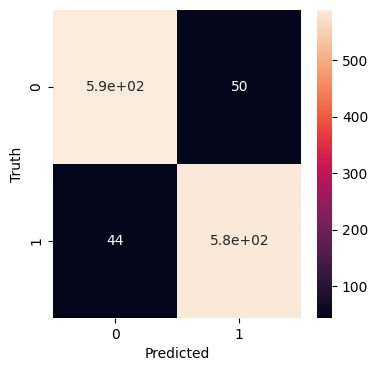

In [128]:
# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on the test data
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {round(accuracy, 3)}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")

# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show();

Let us remember how precision, recall and F1 score are defined:
$$\text{precision} \triangleq \frac{\text{TP}}{\text{TP}+\text{FP}}$$
$$\text{recall} \triangleq \frac{\text{TP}}{\text{TP}+\text{FN}}$$
$$F1 \triangleq 2 \cdot \frac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}$$
These values are already very good. Precision and recall are also practically identical, so there is no need to try to set a threshold for special needs.

#### 2.2 Separated models
Before, we simply merged the title with the text: could this process have caused some inconsistency in the training points?\
Let us test this by separating the training, i.e. construct two classifiers: one based on titles and the other on combined texts. We cannot expect the quality of the predictions made with titles to be sufficient, so we are going to build an unbalanced "voting" system.

In [129]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 3))

Model Accuracy: 0.926


The predictive ability of model1 is lower, although it remains surprisingly close to that obtained before. Let us now add up the contributions of the two models by applying a simple weighted average, where the class probability is computed as:
$$p(C=c) = \frac{w_1\cdot p_1(c) + w_2\cdot p_2(c)}{w_1 + w_2}$$
where $w_i$ is the weight associated to model $i$ and $p_i(c)$ is the probability predicted by model $i$ for the class $c$.

Accuracy and Recall are dominated by the complete model, so it is basically better to choose the naive combination of titles with texts.
Only Precision has the peak for $w_t \neq 0$: this means that, albeit partially, the title analysis can better distinguish TPs from FPs.

#### 2.3 Hyperparameter Tuning
Before trying out other models, we can improve the simple Logistic Regression by setting different hyperparameter values.\
We will perform a **Grid Search** and use a pipeline to streamline the process of fitting and transforming the data. We use the following parameters:
- `tfidf_max_features` is 
- `tfidf_ngram_range = (a, b)`: we consider the n-grams from value a up to value b, 
- `logistic_c` is the inverse regularization strenght: lower values mean stronger regularization (remember the regularized loss function),
- `logistic_penalty` is the type of regularization, either `l2`, which tends to *shrink* the weights towards 0, or `l1`, which tends to *set* the weights to 0 (more strict).

The regressor's argument `max_iter` determines the maximum number of iterations to wait for convergence.

In [130]:
# # FIX: ensure X_train and X_test are usable

# If already Series → convert to string directly
X_train = X_train.astype(str)
X_test = X_test.astype(str)

Accuracy: 0.907
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       639
           1       0.95      0.85      0.90       628

    accuracy                           0.91      1267
   macro avg       0.91      0.91      0.91      1267
weighted avg       0.91      0.91      0.91      1267

Confusion Matrix:


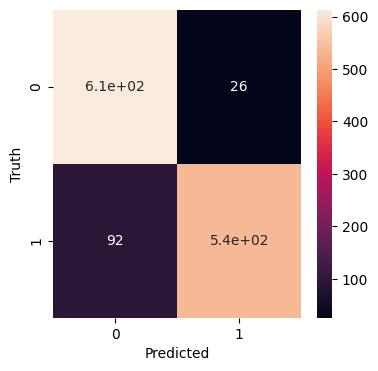

In [131]:
# Evaluate the best model
# Predict on the test data: since the best model pipeline includes the vectorizer, we should give the combined column as input
y_pred = logreg_best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {round(accuracy, 3)}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")

# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show();

In [132]:
import os
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'logistic__C': [0.1, 1, 10],
    'logistic__penalty': ['l2']
}

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('logistic', LogisticRegression(max_iter=1000))
])

if not os.path.exists('models/logreg_best_model.pkl'):
    grid_search = GridSearchCV(pipeline, param_grid, n_jobs=-1, cv=3)
    grid_search.fit(X_train['combined'], y_train['label'])
    logreg_best_model = grid_search.best_estimator_

    joblib.dump(logreg_best_model, 'models/logreg_best_model.pkl')

else:
    logreg_best_model = joblib.load('models/logreg_best_model.pkl')

/Users/josephinesherly/Downloads/TFIDF_FakeNews_detection-main/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.2.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/josephinesherly/Downloads/TFIDF_FakeNews_detection-main/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.2.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/josephinesherly/Downloads/TFIDF_FakeNews_detection-main/venv/lib/python3.14/site-packages/

We therefore achieved an increase of about 2 percentage points on accuracy and F1 score. We keep this model as a reference for the next section.
#### 2.4 Model Selection
Logistic Regression is certainly a model that is easy to interpret, fast and efficient even on large datasets as in this case. However, it is a linear model which, in the case of complex data as in this case, may miss some important details. Below, I list the models we are going to test and the features that might be useful here.


**SVM**: support vector machines are great to classify in spaces with many features (high dimensions) since they effectively create sets of hyperplanes in high-dimensional spaces. They can also handle quite well the *sparsity* of text data.

**Random Forest**: this is a non-linear model which, due to its ‘ensemble’ nature, manages to significantly reduce the risk of overfitting.

**Naive Bayes**: the assumption of independence between the data proves particularly effective in text classification problems, together with the excellent handling of data sparsity. This is one of the most widely used algorithms in this context, and is also quite simple in terms of implementation.

**MLP**: this simple NN is very effective in handling high-dimensional sparse data.

To achieve this comparison, we proceed to construct a new "pipeline", using different models.

In [133]:
import time
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

# Define the model dictionary
models = {
    'svm': SVC(),
    'random_forest': RandomForestClassifier(),
    'naive_bayes': MultinomialNB(),
    'neural_network': MLPClassifier()
}

# Initialize the results dictionary
results = {}

for name, model in models.items():
    start = time.time()

    # FIXED LINE
    model.fit(X_train_tfidf, y_train)

    y_pred_train = model.predict(X_train_tfidf)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'difference': accuracy - accuracy_score(y_train, y_pred_train),
        'report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    end = time.time()
    print(f'Finished training {name}. Time = {round(end-start, 2)} seconds.\n')
    

Finished training svm. Time = 57.46 seconds.

Finished training random_forest. Time = 2.54 seconds.

Finished training naive_bayes. Time = 0.01 seconds.

Finished training neural_network. Time = 14.5 seconds.



In [134]:
# Print the results
for name in results:
    print(f"Results for {name}:")
    print(f"Accuracy: {round(results[name]['accuracy'], 3)}")
    print(f"Train Accuracy: {round(results[name]['train_accuracy'], 3)}")
    print(f"Difference: {round(results[name]['difference'], 3)}")
    print("Classification Report:")
    print(results[name]['report'])
    print("Confusion Matrix:")
    print(results[name]['confusion_matrix'])
    print()

Results for svm:
Accuracy: 0.932
Train Accuracy: 0.996
Difference: -0.064
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       639
           1       0.92      0.94      0.93       628

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267

Confusion Matrix:
[[591  48]
 [ 38 590]]

Results for random_forest:
Accuracy: 0.912
Train Accuracy: 1.0
Difference: -0.088
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       639
           1       0.91      0.91      0.91       628

    accuracy                           0.91      1267
   macro avg       0.91      0.91      0.91      1267
weighted avg       0.91      0.91      0.91      1267

Confusion Matrix:
[[581  58]
 [ 54 574]]

Results for naive_bayes:
Accuracy: 0.901
Train Accuracy: 0.9

In [135]:
# How much does the best logreg model overfit?
logreg_best_model.fit(X_train['combined'], y_train['label'])
y_pred_train = logreg_best_model.predict(X_train['combined'])
y_pred = logreg_best_model.predict(X_test['combined'])

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'Train accuracy: {round(train_accuracy, 3)}')
print(f'Test accuracy: {round(test_accuracy, 3)}')
print(f'Difference: {round(test_accuracy - train_accuracy, 3)}')

KeyError: 'combined'

We therefore conclude that the best model turns out to be the **Multi-Layer Perceptron**, with a result very close to the best configuration of Logistic Regression. However, the neural network is weaker in correctly identifying TPs, as shown in the confusion matrix. 

Given the very short training time for Naive Bayes, coupled with the fact that it is the model that overfills the least, it is worthwhile to perform a grid search with this model, to assess a possible improvement.\
The parameter `alpha` represents a smoothing prior, accounting for features that are not present in the learning samples and prevent zero probabilities. NB estimates the parameters $\theta_y$ with a smoothed version of MLE:
$$\hat{\theta}_{y_i} = \frac{N_{y_i}+\alpha}{N_y+\alpha n}$$ 
where $N_{y_i} = \sum_{x\in T}x_i$ is the number of times feature $i$ appears in a sample of class $y$ in the training set $T$, and $N_y = \sum^n_{i=1}N_{y_i}$ is the total count of all features for class $y$.

In [ ]:
# Define a dictionary with the hyperparameter values: use double underscores to identify the parameters for the different models
param_grid = {
    'tfidf__max_features': [10000, 20000, 30000, 50000],
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'nb__alpha': [0.01, 1.0, 2.0, 10.0, 100.0]
}

# Define the pipeline
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# Since the fitting process is computationally expensive, we will do it only if we do not have the results saved
if not os.path.exists('models/nb_best_model.pkl'):
    # Initialize the GridSearchCV object, with n_jobs=-1 to use all available cores and cv to use 3-fold cross-validation
    grid_search = GridSearchCV(pipeline, param_grid, n_jobs=-1, cv=3, verbose=3)

    # Fit the GridSearchCV object on the combined data: notice that we give the combined column as input, not the vectorized data
    grid_search.fit(X_train['combined'], y_train['label'])
    nb_best_model = grid_search.best_estimator_

    # Save the best model using joblib
    import joblib
    joblib.dump(grid_search.best_estimator_, 'models/nb_best_model.pkl')
    
else:
    # Load the best model using joblib
    nb_best_model = joblib.load('models/nb_best_model.pkl')

In [ ]:
# Evaluate the best NB model
# Predict on the test data: since the best model pipeline includes the vectorizer, we should give the combined column as input
y_pred = nb_best_model.predict(X_test['combined'])

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {round(accuracy, 3)}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show();

We improved the performance of the Naive Bayes classifier, but it still remains below that achieved by the Logistic Regressor. Why?\
Although there are several possible explanations related to the mathematical differences between the two algorithms, in the context of fake news detection the plausible reasons are as follows:
1. NB is an extremely simple model, which may not fully capture the complexity of some of these texts. Also noteworthy is the low possibility of regularisation, from which LR draws a significant advantage.
2. NB's assumption is very strong, which is why it is very powerful with truly independent data. Instead, we know that there is a correlation between the words in the text, albeit limited. Especially in the context of news, we have noticed that there are very recurrent n-grams, an aspect that cannot be overlooked.
3. NB tends to be strongly influenced by rare data (words). In the previous notebook, we discussed the importance of recognising the most relevant words and ‘neglecting’ the contribution of rarer ones through TFIDF vectorization.

In conclusion, a classifier that is simple and quick to train is sufficient for this project: **Logistic Regression**.